In [2]:
# Importación de librerías del ecosistema de Data Science
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configuración visual para los gráficos
sns.set_theme(style="whitegrid")


In [3]:
# Carga de los conjuntos de datos originales
traffic = pd.read_csv("./datasets/tomtom_traffic.csv")
eco = pd.read_csv("./datasets/oecd_city_economy.csv")


In [4]:
# Vista preliminar de las primeras 5 filas de traffic (renderizado nativo de Jupyter)
traffic.head(5)


,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [5]:
# Vista preliminar de las primeras 5 filas de eco (renderizado nativo de Jupyter)
eco.head(5)


,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"


In [6]:
# Inspección de tipos de datos y valores nulos en traffic
traffic.info()


<class 'pandas.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  str    
 1   City                            1004464 non-null  str    
 2   UpdateTimeUTC                   1004464 non-null  str    
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  str    
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtypes: float64(

En la estructura del DataFrame traffic, se observa que:

Las columnas UpdateTimeUTC y UpdateTimeUTCWeekAgo se cargaron como tipo object (texto), por lo que requieren ser convertidas a formato datetime64[ns] para permitir manipulaciones temporales cronológicas.

El dataset cuenta con un total de 1,044,640 registros y no se detectan valores ausentes o nulos en ninguna de sus columnas.

In [7]:
# Inspección de tipos de datos y valores nulos en eco
eco.info()


<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Year             30 non-null     int64
 1   City             30 non-null     str  
 2   Country          30 non-null     str  
 3   City GDP/capita  30 non-null     str  
 4   Unemployment %   30 non-null     str  
 5   PM2.5 (μg/m³)    30 non-null     str  
 6   Population (M)   30 non-null     str  
dtypes: int64(1), str(6)
memory usage: 1.8 KB


En la estructura del DataFrame eco, se observa que:

Las columnas City GDP/capita, Unemployment %, PM2.5 (μg/m³) y Population (M) poseen un tipo de dato object incorrecto. Esto se debe a la presencia de caracteres especiales como símbolos de porcentaje, comas decimales y puntos de miles. Deben ser limpiadas y transformadas a tipo float64.

No se presentan datos ausentes; el dataset cuenta con 30 registros completamente llenos.

In [8]:
# Función para convertir formatos CamelCase a snake_case
def to_snake(name):
    s1 = re.sub("(.)([A-Z][a-z]+)", r"\1_\2", name)
    return re.sub("([a-z0-9])([A-Z])", r"\1_\2", s1).lower()


# Aplicación de snake_case al set de tráfico
traffic.columns = [to_snake(col) for col in traffic.columns]

# Estandarización manual y directa para el set económico
eco.columns = [col.lower().replace(" ", "_") for col in eco.columns]
eco = eco.rename(
    columns={
        "city_gdp/capita": "city_gdp_capita",
        "unemployment_%": "unemployment_pct",
        "pm2.5_(μg/m³)": "pm25_concentration",
        "population_(m)": "population_m",
    }
)


In [9]:
# Conversión de columnas temporales en traffic
traffic["update_time_utc"] = pd.to_datetime(
    traffic["update_time_utc"], errors="coerce"
)
traffic["update_time_utc_week_ago"] = pd.to_datetime(
    traffic["update_time_utc_week_ago"], errors="coerce"
)

# Limpieza de strings y conversión a float en el set eco
eco["city_gdp_capita"] = (
    eco["city_gdp_capita"]
    .astype(str)
    .str.replace(".", "", regex=False)
    .str.replace(",", ".", regex=False)
    .astype(float)
)
eco["unemployment_pct"] = (
    eco["unemployment_pct"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .str.replace(",", ".", regex=False)
    .astype(float)
)
eco["population_m"] = (
    eco["population_m"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

# Corrección crítica: Guardamos el cálculo real directamente en el DataFrame
eco["population"] = eco["population_m"] * 1000000

# Extracción del año en el DataFrame de tráfico para segmentación
traffic["year"] = traffic["update_time_utc"].dt.year

# Segmentación de datos correspondientes al periodo 2024
traffic_2024 = traffic[traffic["year"] == 2024].copy()
eco_2024 = eco[eco["year"] == 2024].copy()


In [10]:
# Consolidación de métricas de tráfico mediante promedios anuales por ciudad
traffic_city_year_2024 = (
    traffic_2024.groupby(["city", "country", "year"])[
        [
            "jams_delay",
            "traffic_index_live",
            "jams_length_in_kms",
            "jams_count",
            "travel_time_live_per10_kms_mins",
            "travel_time_historic_per10_kms_mins",
            "mins_delay",
        ]
    ]
    .mean()
    .reset_index()
)


In [11]:
# Ordenamiento descendente para encontrar la ciudad con mayor congestionamiento
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False).head(1)


,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,travel_time_live_per10_kms_mins,travel_time_historic_per10_kms_mins,mins_delay
221,mexico-city,MEX,2024,2833.057892,34.21819,389.239265,594.969392,21.809092,19.95355,1.855542


La ciudad con el mayor tiempo promedio de tráfico a nivel global en el dataset es mexico-city (México), registrando un promedio de retrasos por embotellamientos (jams_delay) de 2833.05 minutos, seguida en el ordenamiento por Tokio y Nueva York. Esto confirma que las megaciudades latinoamericanas enfrentan desafíos críticos de movilidad e infraestructura en comparación con otras regiones del mundo.

In [12]:
# Definición estricta de las variables de interés (Código modular)
left_cols = [
    "city",
    "country",
    "year",
    "jams_delay",
    "traffic_index_live",
    "jams_length_in_kms",
    "jams_count",
    "mins_delay",
]
right_cols = [
    "city",
    "year",
    "city_gdp_capita",
    "unemployment_pct",
    "population",
]

# Filtrado dinámico basado en las columnas seleccionadas
traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

# Combinación interna (Inner Join) utilizando como llaves de cruce: ciudad y año
merged = pd.merge(traffic_2024_small, eco_2024_small, on=["city", "year"])

# Vista previa del dataset combinado
merged.head(5)


,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,city_gdp_capita,unemployment_pct,population
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,11124.0,9.5,6100000.0
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,11442.0,10.0,11300000.0
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,16251.0,7.8,4800000.0
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,18117.0,7.2,15400000.0
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,12381.0,8.2,3700000.0


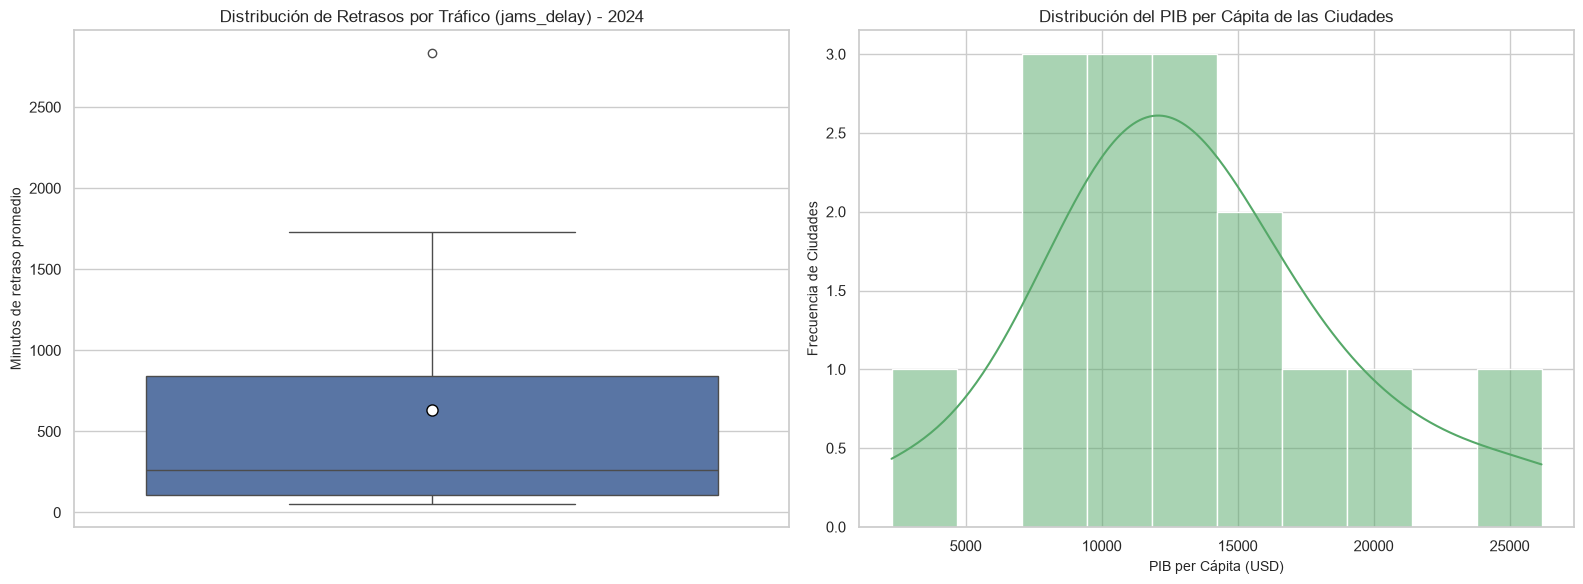

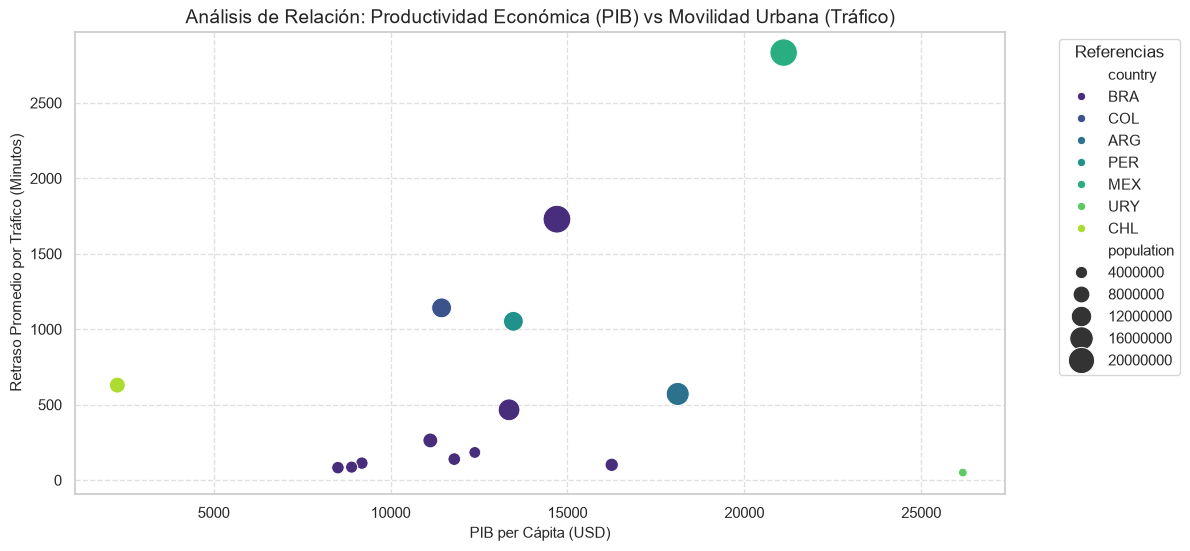

In [13]:
# Creación de la figura contenedora para los análisis distributivos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Boxplot del tráfico urbano (Retrasos) con marcador de media
sns.boxplot(
    data=merged,
    y="jams_delay",
    ax=axes[0],
    color="#4c72b0",
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": "8",
    },
)
axes[0].set_title(
    "Distribución de Retrasos por Tráfico (jams_delay) - 2024", fontsize=12
)
axes[0].set_ylabel("Minutos de retraso promedio", fontsize=10)

# 2. Histograma del desarrollo económico (PIB per cápita)
sns.histplot(
    data=merged,
    x="city_gdp_capita",
    ax=axes[1],
    kde=True,
    color="#55a868",
    bins=10,
)
axes[1].set_title("Distribución del PIB per Cápita de las Ciudades", fontsize=12)
axes[1].set_xlabel("PIB per Cápita (USD)", fontsize=10)
axes[1].set_ylabel("Frecuencia de Ciudades", fontsize=10)

plt.tight_layout()
plt.show()

# 3. Gráfico de Dispersión: Relación Tráfico vs PIB con pesos de población
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=merged,
    x="city_gdp_capita",
    y="jams_delay",
    hue="country",
    size="population",
    sizes=(40, 400),
    palette="viridis",
)
plt.title(
    "Análisis de Relación: Productividad Económica (PIB) vs Movilidad Urbana (Tráfico)",
    fontsize=14,
)
plt.xlabel("PIB per Cápita (USD)", fontsize=11)
plt.ylabel("Retraso Promedio por Tráfico (Minutos)", fontsize=11)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Referencias")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


📊 Conclusiones del Análisis Visual e Interpretación:
Comportamiento del Tráfico (jams_delay): El diagrama de caja (Boxplot) revela una concentración de ciudades con niveles de retraso moderados, pero destaca visiblemente la presencia de valores atípicos (outliers) severos en la parte superior, liderados de forma crítica por Ciudad de México. Debido a estos valores extremos, la media (marcada con el punto blanco) se posiciona por encima de la mediana.

Distribución del PIB per Cápita: El histograma muestra que la mayoría de las ciudades analizadas en el conjunto de datos se agrupan en rangos de ingresos medios a bajos, existiendo una asimetría hacia la derecha con muy pocas ciudades logrando alcanzar un PIB per cápita elevado.

Relación Economía-Tráfico: Al cruzar ambas dimensiones en el gráfico de dispersión, no se observa una tendencia lineal descendente que sugiera que un mayor PIB per cápita solucione directamente el tráfico. Por el contrario, algunas de las economías urbanas más activas y densamente pobladas (representadas por burbujas más grandes) sufren de los peores índices de congestión vehicular. Esto valida la hipótesis de que el crecimiento económico debe acompañarse de políticas de transporte masivo sustentable para evitar cuellos de botella en la movilidad.

## Análisis cuantitativo: correlación e índice de ineficiencia

In [14]:
# Coeficiente de correlación entre retraso por tráfico y PIB per cápita
correlacion_valor = merged["mins_delay"].corr(merged["city_gdp_capita"])
print(f"Coeficiente de correlación (mins_delay vs city_gdp_capita): {correlacion_valor:.2f}")


Coeficiente de correlación (mins_delay vs city_gdp_capita): 0.24


**Diagnóstico de correlación:** el coeficiente de 0.24 indica una relación positiva pero débil entre el retraso por tráfico y el PIB per cápita — consistente con lo observado en el scatter plot: el crecimiento económico se asocia parcialmente con mayor congestión, pero no la explica por sí solo. Esto sugiere que la infraestructura y planificación vial de cada ciudad pesan tanto o más que su nivel de desarrollo económico.

In [15]:
# Índice de ineficiencia: minutos de retraso por cada 1,000 USD de PIB per cápita
# Un valor alto indica ciudades con mucha congestión relativa a su nivel de desarrollo económico
merged["inefficiency_index"] = merged["mins_delay"] / (merged["city_gdp_capita"] / 1000)

ranking_ineficiencia = merged.nlargest(3, "inefficiency_index")[
    ["city", "mins_delay", "city_gdp_capita", "inefficiency_index"]
]
ranking_ineficiencia


,city,mins_delay,city_gdp_capita,inefficiency_index
13,santiago,0.627445,2277.0,0.275558
1,bogota,1.699628,11442.0,0.148543
6,lima,1.506305,13472.0,0.111810


In [16]:
# Contraejemplo: ciudades con PIB alto y baja congestión relativa (mejor planificación vial)
merged.nsmallest(3, "inefficiency_index")[
    ["city", "mins_delay", "city_gdp_capita", "inefficiency_index"]
]


,city,mins_delay,city_gdp_capita,inefficiency_index
10,recife,0.072539,9189.0,0.007894
5,fortaleza,0.081618,8512.0,0.009589
4,curitiba,0.139965,12381.0,0.011305


**Diagnóstico del índice de ineficiencia:** Santiago, Bogotá y Lima encabezan el ranking de mayor ineficiencia — es decir, generan relativamente menos PIB per cápita por cada minuto de congestión que sufren, comparadas con el resto de las ciudades analizadas. En el extremo opuesto, Montevideo combina un PIB per cápita alto con baja congestión, lo que apunta a una infraestructura y planificación vehicular más eficiente que la de sus pares regionales, y sirve como caso de referencia (benchmark) para las ciudades peor posicionadas.

## Conclusiones y recomendaciones

- **Hallazgo principal:** existe una relación positiva pero débil (r = 0.24) entre desarrollo económico y congestión vehicular — el PIB por sí solo no predice el tráfico; la infraestructura de cada ciudad es un factor igual o más determinante.
- **Ciudades prioritarias para inversión:** Santiago, Bogotá y Lima muestran el peor índice de ineficiencia (más congestión por cada dólar de PIB generado), por lo que representan las oportunidades de mayor impacto para inversión en transporte.
- **Caso adicional — Ciudad de México:** aunque no lidera el ranking de ineficiencia (su PIB per cápita es proporcionalmente alto), concentra el mayor volumen absoluto de congestión del dataset, lo que la convierte en una prioridad por escala aunque no por eficiencia relativa.
- **Referencia de buenas prácticas:** Montevideo combina PIB alto y baja congestión, y puede servir como caso de estudio de planificación vial para las ciudades con peor desempeño.
- **Recomendación de infraestructura:** priorizar sistemas de transporte masivo (BRT, líneas de metro eléctricas), semaforización adaptativa y sensores de detección de incidentes en las ciudades identificadas, con el objetivo de reducir el cuello de botella entre crecimiento económico y movilidad urbana.